In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1. tensorflow v2.xx 에서 v1 사용하기

In [2]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior() # v2를 비활성화하고 v1 활성화
import numpy as np
import pandas as pd

Instructions for updating:
non-resource variables are not supported in the long term


## Tensorflow
- 데이터 흐름 그래프(tensor 객체의 흐름)
- 이 그래프는 node(상수, 변수, 연산)와 edge로 구성
- sess = tf.Session()으로 실행
- sess.run()을 통해 값을 확인

In [3]:
# tensor = data(상수, 변수)와 연산
node1 = tf.constant('Hello Tensorflow')
sess = tf.Session() # tensorflow 전원장치 Session()
print(sess.run(node1).decode())

Hello Tensorflow


In [4]:
# 간단한 연산 tensor 그래프
node1 = tf.constant(10, dtype = tf.float16)
node2 = tf.constant(20, dtype = tf.float16)
node3 = tf.add(node1, node2)
sess = tf.Session()
print(sess.run([node1, node2, node3]))

[10.0, 20.0, 30.0]


In [5]:
# 타입 변경
node1 = tf.constant(np.array([1,2,3]), dtype=tf.int16)
node2 = tf.cast(node1, dtype = tf.float32)
sess = tf.Session()
sess.run([node1, node2])

[array([1, 2, 3], dtype=int16), array([1., 2., 3.], dtype=float32)]

In [6]:
# 평균값 계산 : tf.reduce_mean()
data = np.array([1,2,3.,])
tensor = tf.reduce_mean(data) # sess.run 하면 평균값을 계산할 예정이다
sess = tf.Session()
sess.run(tensor)

2.0

In [7]:
# random값을 갖는 tensor => 스케일 조정을 평균이 0, 표준편차가 1인 정규분포를 주로 이용
tensor = tf.random_normal([2]) # 평균이 0, 표준편차가 1인, 난수 실수 2개(정규분포를 이루는 난수)
a = tf.random_normal([1]) # 평균이 0, 표준편차가 1인, 난수 실수 1개(정규분포를 이루는 난수)
b = tf.random_normal([1]) # 평균이 0, 표준편차가 1인, 난수 실수 1개(정규분포를 이루는 난수)
sess = tf.Session()
sess.run([a,b])
# sess.run(tensor)

[array([0.8325035], dtype=float32), array([-2.1124563], dtype=float32)]

In [8]:
w = tf.Variable(tf.random_normal([1])) # 학습에 따라 변화하는, 변수로 가중치 설정
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w 변수의 난수 초기화
sess.run(w)

array([-1.8405759], dtype=float32)

# 2. tensorflow v1을 이용한 linear regression을 구현
## 2.1 독립(입력)변수 x가 1개, 종속(타겟)변수 y가 1개

In [9]:
x = np.array([1,2,3])
y = np.array([2,3,4])
# weight와 bias(처음에는 랜덤값으로 셋팅, 학습과정에서 변경)
w = tf.Variable(tf.random_normal([1]), name = 'weight')
b = tf.Variable(tf.random_normal([1]), name = 'bias')
# Hypothesis : 예측값(가설)
H = w*x + b
# cost function(손실함수 : loss, mse; 최소제곱법)
cost = tf.reduce_mean(tf.square(H-y))
'''
학습 목적 : cost가 최소가 되는 w, b를 찾아내는 것
cost는 2차 함수이므로 곡선그래프. 곡선위 미분값이 줄어드는 방향으로 학습(경사하강;Gradient descent Optimizer)
'''
optimizer = tf.train.GradientDescentOptimizer(learning_rate = 0.01) # 미분값
train = optimizer.minimize(cost)
# Session생성
sess = tf.Session()
# w,b 변수 노드의 초기화
sess.run(tf.global_variables_initializer())
# 학습 5000번(v2에서 fit함수)
for step in range(1,5001):
    _, cost_val, w_val, b_val = sess.run([train, cost, w, b])
    if step%200 == 0 :
        print(f'{step}번째 cost : {cost_val}, w : {w_val}, b : {b_val}')

200번째 cost : 0.1802210807800293, w : [1.4918736], b : [-0.11814442]
400번째 cost : 0.06881723552942276, w : [1.3039479], b : [0.3090547]
600번째 cost : 0.026277795433998108, w : [1.1878214], b : [0.5730378]
800번째 cost : 0.01003412064164877, w : [1.116062], b : [0.7361637]
1000번째 cost : 0.0038315134588629007, w : [1.0717193], b : [0.83696514]
1200번째 cost : 0.0014630580553784966, w : [1.0443182], b : [0.8992545]
1400번째 cost : 0.0005586661281995475, w : [1.0273858], b : [0.93774533]
1600번째 cost : 0.0002133244852302596, w : [1.0169227], b : [0.96153057]
1800번째 cost : 8.145912579493597e-05, w : [1.0104575], b : [0.976228]
2000번째 cost : 3.110579200438224e-05, w : [1.006462], b : [0.9853102]
2200번째 cost : 1.1877817996719386e-05, w : [1.0039933], b : [0.9909225]
2400번째 cost : 4.535809694061754e-06, w : [1.0024676], b : [0.99439055]
2600번째 cost : 1.7326437955489382e-06, w : [1.0015252], b : [0.99653316]
2800번째 cost : 6.620948624913581e-07, w : [1.000943], b : [0.997857]
3000번째 cost : 2.533126064463

In [10]:
# 최종적으로 나온 회귀식 : H = w*x + b
sess.run([w,b])

[array([1.0000087], dtype=float32), array([0.9999811], dtype=float32)]

In [11]:
w_, b_ = sess.run([w,b])
w_[0], b_[0]


(1.0000087, 0.9999811)

In [12]:
def predict(int_x) :
    return w_[0]*int_x + b_[0]

In [13]:
input_x = int(input('입력값은? : '))
print('예측값은 : ',predict(input_x))

입력값은? : 1
예측값은 :  1.9999898076057434


## 2.2 predict를 위한 placeholder 이용
- placeholder : 텐서플로우 외부에서 데이터를 입력 받는 노드

In [14]:
# x = np.array([1,2,3])
x = tf.placeholder(dtype=tf.float16) # 데이터는 전원(Session() 객체가 호출된 후에) 기입
H = 1*x + 1
sess = tf.Session()
sess.run(H, feed_dict={x:5})
sess.run(H, feed_dict={x:np.array([1,2,3])})

array([2., 3., 4.], dtype=float16)

In [15]:
# data placeholder 설정
# H = 2x + 1
x_data = [1,2,3,5,8]
y_data = [3,5,7,11,17]
x = tf.placeholder(tf.float32) 
y = tf.placeholder(tf.float32) 
# 가중치 설정
w = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# 가설 설정
H = w*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
optimizer = tf.train.GradientDescentOptimizer(learning_rate = 0.01)
train = optimizer.minimize(cost)
# 학습
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w, b 초기화
for step in range(5001) :
    _, cost_val, w_val, b_val = sess.run([train, cost, w, b] , feed_dict={x : x_data, y : y_data})
    if step%200 == 0 :
        print(f'{step}번째 : cost : {cost_val}, w : {w_val}, b : {b_val}')

0번째 : cost : 32.30292510986328, w : [1.6656251], b : [-0.9911169]
200번째 : cost : 0.10335931926965714, w : [2.1093328], b : [0.41561776]
400번째 : cost : 0.010166240856051445, w : [2.0342891], b : [0.8167251]
600번째 : cost : 0.0009999340400099754, w : [2.0107539], b : [0.94252104]
800번째 : cost : 9.835168020799756e-05, w : [2.0033727], b : [0.9819734]
1000번째 : cost : 9.675200089986902e-06, w : [2.0010579], b : [0.9943463]
1200번째 : cost : 9.515133569948375e-07, w : [2.0003319], b : [0.9982268]
1400번째 : cost : 9.361983899225379e-08, w : [2.000104], b : [0.999444]
1600번째 : cost : 9.27852816801078e-09, w : [2.0000327], b : [0.9998251]
1800번째 : cost : 9.165887493445268e-10, w : [2.0000105], b : [0.999945]
2000번째 : cost : 9.972609543718036e-11, w : [2.0000036], b : [0.99998176]
2200번째 : cost : 2.060005464821213e-11, w : [2.0000017], b : [0.99999213]
2400번째 : cost : 2.060005464821213e-11, w : [2.0000017], b : [0.99999213]
2600번째 : cost : 2.060005464821213e-11, w : [2.0000017], b : [0.99999213]
280

In [16]:
# 예측하기 predict
sess.run(H, feed_dict={x:5})

array([11.000001], dtype=float32)

In [17]:
sess.run(H, feed_dict={x : np.array([5,6,7])})

array([11.000001, 13.000002, 15.000004], dtype=float32)

## 2.3 scale이 다른 데이터의 linear regression 구현(scale 조정x)

In [18]:
# data placeholder 설정
x_data = [1,2,5,8,10]
y_data = [3,15,68,80,95]
x = tf.placeholder(tf.float32) 
y = tf.placeholder(tf.float32) 
# 가중치 설정
w = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# 가설 설정
H = w*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
optimizer = tf.train.GradientDescentOptimizer(learning_rate = 0.01)
train = optimizer.minimize(cost)
# 학습
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w, b 초기화
for step in range(5001) :
    _, cost_val, w_val, b_val = sess.run([train, cost, w, b] , feed_dict={x : x_data, y : y_data})
    if step%200 == 0 :
        print(f'{step}번째 : cost : {cost_val}, w : {w_val}, b : {b_val}') # 코스트가 쉽게 줄어들지 않음

0번째 : cost : 3259.247314453125, w : [8.133046], b : [0.6290105]
200번째 : cost : 83.62541961669922, w : [10.210472], b : [-0.69110835]
400번째 : cost : 83.49544525146484, w : [10.274779], b : [-1.1672615]
600번째 : cost : 83.48353576660156, w : [10.294258], b : [-1.3114848]
800번째 : cost : 83.48243713378906, w : [10.300158], b : [-1.3551688]
1000번째 : cost : 83.48233795166016, w : [10.301945], b : [-1.3684001]
1200번째 : cost : 83.48231506347656, w : [10.302486], b : [-1.3724077]
1400번째 : cost : 83.48230743408203, w : [10.3026495], b : [-1.3736222]
1600번째 : cost : 83.4823226928711, w : [10.302699], b : [-1.3739895]
1800번째 : cost : 83.48231506347656, w : [10.302714], b : [-1.3741001]
2000번째 : cost : 83.48233032226562, w : [10.302718], b : [-1.3741323]
2200번째 : cost : 83.48233032226562, w : [10.302718], b : [-1.3741326]
2400번째 : cost : 83.48233032226562, w : [10.302718], b : [-1.3741326]
2600번째 : cost : 83.48233032226562, w : [10.302718], b : [-1.3741326]
2800번째 : cost : 83.48233032226562, w : [10

In [19]:
# cost값이 멈춤 : Local 최소값 (Local Minima)에 빠졌을 때를 대비할 수 있음. 

## 2.4 scale이 다른 데이터의 Linear Regression을 구현(scale 조정O)
### scale을 맞추기 : 모든 데이터를 일정 범위 내로 조정
- normalization(정규화) : 데이터를 0 ~ 1 로 조정
                      X - Xmin
    normalization = ---------------------------------------------
                      Xmax - Xmin
                  * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.MinMaxScaler 이용)
                  
- standardization(표준화) : 평균 0, 표준편차 1로 조정
                        X - Xmean(평균)
    standardization = ------------------------------------------------ 
                        Xstd(표준편차)
                  * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.StandardScaler 이용)

In [20]:
# 1. 라이브러리 쓰지 않고 정규화
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
scaled_x_data = (x_data - x_data.min())/(x_data.max()-x_data.min())
scaled_y_data = (y_data - y_data.min())/(y_data.max()-y_data.min())
scaled_x_data, scaled_y_data

(array([0.        , 0.11111111, 0.44444444, 0.77777778, 1.        ]),
 array([0.        , 0.13043478, 0.70652174, 0.83695652, 1.        ]))

In [21]:
# 2. 라이브러리 쓰고 정규화 (MinMaxScaler 이용)
from sklearn.preprocessing import MinMaxScaler
x_data = np.array([1,2,5,8,10]).reshape(-1,1)
y_data = np.array([3,15,68,80,95]).reshape(-1,1)
# np.column_stack([x_data,y_data])
scaler_x = MinMaxScaler() # x데이터를 정규화 시킬 객체(2차원만 가능)
scaler_y = MinMaxScaler() # y데이터를 정규화 시킬 객체
# scaler_x.fit(x_data)
# scaled_x_data = scaler_x.transform(x_data)
scaled_x_data = scaler_x.fit_transform(x_data)
scaled_y_data = scaler_y.fit_transform(y_data)
np.column_stack([x_data,y_data,scaled_x_data,scaled_y_data])

array([[ 1.        ,  3.        ,  0.        ,  0.        ],
       [ 2.        , 15.        ,  0.11111111,  0.13043478],
       [ 5.        , 68.        ,  0.44444444,  0.70652174],
       [ 8.        , 80.        ,  0.77777778,  0.83695652],
       [10.        , 95.        ,  1.        ,  1.        ]])

In [22]:
x = tf.placeholder(tf.float32) 
y = tf.placeholder(tf.float32) 
# 가중치 설정
w = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# 가설 설정
H = w*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
optimizer = tf.train.GradientDescentOptimizer(learning_rate = 0.001)
train = optimizer.minimize(cost)
# 학습
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w, b 초기화
for step in range(120000) :
    _, cost_val, w_val, b_val = sess.run([train, cost, w, b] , feed_dict={x : scaled_x_data, y : scaled_y_data})
    if step%500 == 0 :
        print(f'{step}번째 : cost : {cost_val}, w : {w_val}, b : {b_val}') # 코스트가 쉽게 줄어들지 않음

0번째 : cost : 2.3627119064331055, w : [-1.0860212], b : [-0.26458445]
500번째 : cost : 0.442171573638916, w : [-0.49844375], b : [0.44812158]
1000번째 : cost : 0.2343558967113495, w : [-0.23023085], b : [0.6001398]
1500번째 : cost : 0.17797836661338806, w : [-0.06464203], b : [0.5969848]
2000번째 : cost : 0.14223802089691162, w : [0.06174516], b : [0.55442995]
2500번째 : cost : 0.11466068029403687, w : [0.16820827], b : [0.50514483]
3000번째 : cost : 0.09287526458501816, w : [0.2612349], b : [0.4580039]
3500번째 : cost : 0.07562251389026642, w : [0.34353536], b : [0.41510618]
4000번째 : cost : 0.06195579096674919, w : [0.41664368], b : [0.3766558]
4500번째 : cost : 0.05112951993942261, w : [0.48167148], b : [0.34235597]
5000번째 : cost : 0.042553193867206573, w : [0.53953755], b : [0.31180537]
5500번째 : cost : 0.03575928509235382, w : [0.5910372], b : [0.2846079]
6000번째 : cost : 0.030377332121133804, w : [0.6368731], b : [0.26039904]
6500번째 : cost : 0.026113858446478844, w : [0.67766917], b : [0.23885153]
7

57000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
57500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
58000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
58500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
59000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
59500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
60000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
60500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
61000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
61500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
62000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
62500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
63000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
63500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0

114000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
114500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
115000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
115500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
116000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
116500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
117000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
117500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
118000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
118500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
119000번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]
119500번째 : cost : 0.009863230399787426, w : [1.0076637], b : [0.0645414]


In [23]:
# 예측 : 모델에 scale 조정된 값으로 예측 => scale 조정된 y값 반환
scaled_input = scaler_x.transform(np.array([[2],
                                           [3]]))
print('모델 예측을 위한 입력 :',scaled_input, sep='\n')
scaled_output = sess.run(H, feed_dict={x:scaled_input})
print('모델 예측 결과 :',scaled_output, sep='\n')
print('결과 : ',scaler_y.inverse_transform(scaled_output),sep='\n')

모델 예측을 위한 입력 :
[[0.11111111]
 [0.22222222]]
모델 예측 결과 :
[[0.17650405]
 [0.2884667 ]]
결과 : 
[[19.238373]
 [29.538935]]


In [24]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat) # 기존 [3,15,68,80,95]
y_hat

array([[  8.937809],
       [ 19.238373],
       [ 50.140057],
       [ 81.04175 ],
       [101.64287 ]], dtype=float32)

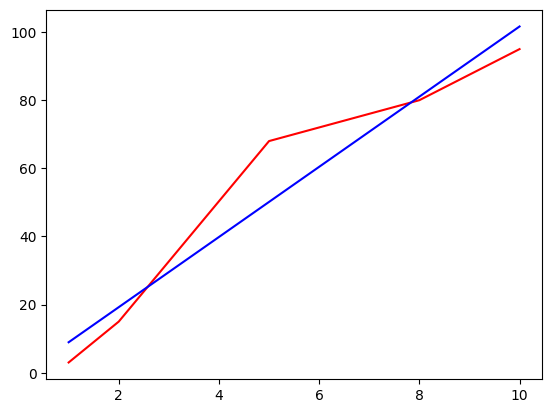

In [25]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')

In [26]:
# 라이브러리를 사용하여 표준화(standardization) : StandardScaler
from sklearn.preprocessing import StandardScaler
x_data, y_data
x_scaler = StandardScaler() # x_data를 표준화할 객체
y_scaler = StandardScaler() # y_data를 표준화할 객체
scaled_x_data = x_scaler.fit_transform(x_data)
scaled_y_data = y_scaler.fit_transform(y_data)
print(np.column_stack([x_data,y_data]))
print(np.column_stack([scaled_x_data,scaled_y_data]))

[[ 1  3]
 [ 2 15]
 [ 5 68]
 [ 8 80]
 [10 95]]
[[-1.22474487 -1.34819316]
 [-0.93313895 -1.01936556]
 [-0.05832118  0.43295634]
 [ 0.81649658  0.76178394]
 [ 1.39970842  1.17281844]]


In [27]:
x = tf.placeholder(tf.float32) 
y = tf.placeholder(tf.float32) 
# 가중치 설정
w = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# 가설 설정
H = w*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
optimizer = tf.train.GradientDescentOptimizer(learning_rate = 0.001)
train = optimizer.minimize(cost)
# 학습
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w, b 초기화
for step in range(12000) :
    _, cost_val, w_val, b_val = sess.run([train, cost, w, b] , feed_dict={x : scaled_x_data, y : scaled_y_data})
    if step%500 == 0 :
        print(f'{step}번째 : cost : {cost_val}, w : {w_val}, b : {b_val}') # 코스트가 쉽게 줄어들지 않음

0번째 : cost : 0.5001987814903259, w : [0.35172036], b : [-0.23617655]
500번째 : cost : 0.12177813053131104, w : [0.7416053], b : [-0.08679748]
1000번째 : cost : 0.07066693902015686, w : [0.88489246], b : [-0.03189904]
1500번째 : cost : 0.06376367807388306, w : [0.9375518], b : [-0.01172324]
2000번째 : cost : 0.06283130496740341, w : [0.9569045], b : [-0.00430841]
2500번째 : cost : 0.06270536780357361, w : [0.96401685], b : [-0.00158338]
3000번째 : cost : 0.06268836557865143, w : [0.96663094], b : [-0.0005819]
3500번째 : cost : 0.06268606334924698, w : [0.9675915], b : [-0.00021385]
4000번째 : cost : 0.06268574297428131, w : [0.9679444], b : [-7.8583726e-05]
4500번째 : cost : 0.06268570572137833, w : [0.9680749], b : [-2.887266e-05]
5000번째 : cost : 0.06268571317195892, w : [0.96812], b : [-1.0602922e-05]
5500번째 : cost : 0.06268568336963654, w : [0.96813506], b : [-3.8826756e-06]
6000번째 : cost : 0.06268568336963654, w : [0.96813506], b : [-1.4099343e-06]
6500번째 : cost : 0.06268569827079773, w : [0.96813506

In [28]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = y_scaler.inverse_transform(scaled_y_hat) # 기존 [3,15,68,80,95]
y_hat

array([[  8.929233],
       [ 19.2318  ],
       [ 50.13949 ],
       [ 81.04718 ],
       [101.6523  ]], dtype=float32)

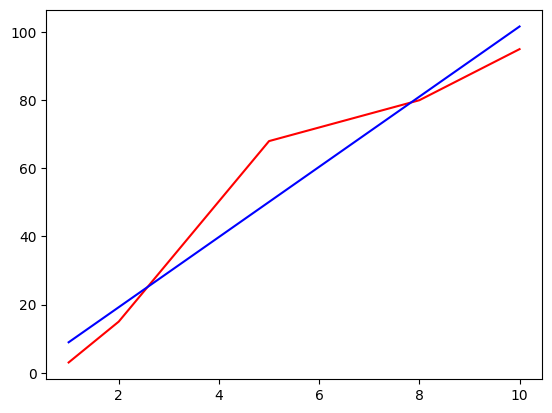

In [29]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')

## 2.5 입력(독립)변수 x가 3개, 타겟(종속)변수 y가 1개

In [39]:
# 방법1. csv -> np.array 결측치가 있으면 추천하지 않음
import numpy as np
# data = np.loadtxt('data/pima-indians-diabetes.csv',encoding='utf-8' ,delimiter=',') # 결측치와 header가 없어야 활용 가능
data = np.genfromtxt('data/ozone.csv',
                     delimiter=',',
                    skip_header=1,
                    missing_values='NA',
                    filling_values=np.nan)
data

array([[ 41. , 190. ,   7.4,  67. ,   5. ,   1. ],
       [ 36. , 118. ,   8. ,  72. ,   5. ,   2. ],
       [ 12. , 149. ,  12.6,  74. ,   5. ,   3. ],
       [ 18. , 313. ,  11.5,  62. ,   5. ,   4. ],
       [  nan,   nan,  14.3,  56. ,   5. ,   5. ],
       [ 28. ,   nan,  14.9,  66. ,   5. ,   6. ],
       [ 23. , 299. ,   8.6,  65. ,   5. ,   7. ],
       [ 19. ,  99. ,  13.8,  59. ,   5. ,   8. ],
       [  8. ,  19. ,  20.1,  61. ,   5. ,   9. ],
       [  nan, 194. ,   8.6,  69. ,   5. ,  10. ],
       [  7. ,   nan,   6.9,  74. ,   5. ,  11. ],
       [ 16. , 256. ,   9.7,  69. ,   5. ,  12. ],
       [ 11. , 290. ,   9.2,  66. ,   5. ,  13. ],
       [ 14. , 274. ,  10.9,  68. ,   5. ,  14. ],
       [ 18. ,  65. ,  13.2,  58. ,   5. ,  15. ],
       [ 14. , 334. ,  11.5,  64. ,   5. ,  16. ],
       [ 34. , 307. ,  12. ,  66. ,   5. ,  17. ],
       [  6. ,  78. ,  18.4,  57. ,   5. ,  18. ],
       [ 30. , 322. ,  11.5,  68. ,   5. ,  19. ],
       [ 11. ,  44. ,   9.7,  6

In [45]:
# 방법2. csv -> DataFrame -> 결측치처리 -> np.array -> 머신러닝
# 1. csv를 데이터프레임으로 읽기
import pandas as pd
data = pd.read_csv('data/ozone.csv')
data.info() # Ozone, Solar.R열에만 결측치
data.isna().sum() # 열별 결측치 개수

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 7.3 KB


Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

In [131]:
# 결측치 처리
# 결측치 처리 방법 1. 결측치가 있는 행을 제거
# data.dropna(how='any',axis=0, inplace=True)
# 결측치 처리 방법 2. 열별 평균값으로 대체
# data.mean(axis=0) # 열별 평균
# data.fillna(value = data.mean()).isna().sum() # 계절성 요소가 고려되지 않음(월별 변화가 고려되지 않음)
# 결측치 처리 방법 3. 결측치 대체(월별 열별 평균값으로 대체)
mean_data = data.groupby(['Month'])[['Ozone','Solar.R']].mean()
display(mean_data)
print('5월에 Ozone으로 대체할 값 : ',mean_data.loc[5,'Ozone'])
data.loc[4] # Ozone, Solar.R 결측치

,Ozone,Solar.R
Month,,
5,23.615385,181.296296
6,29.444444,190.166667
7,59.115385,216.483871
8,59.961538,171.857143
9,31.448276,167.433333


5월에 Ozone으로 대체할 값 :  23.615384615384617


Ozone       NaN
Solar.R     NaN
Wind       14.3
Temp       56.0
Month       5.0
Day         5.0
Name: 4, dtype: float64

In [127]:
# data.loc[4][data.loc[4].isna()]
# data_sample = data.loc[4].copy()
# data_sample.Ozone = 1
# data_sample
def fill_nan(row) :
    row = row.copy()
    if np.isnan(row.loc['Ozone']):
        row.loc['Ozone'] = mean_data.loc[row.loc['Month'],'Ozone']
    if np.isnan(row.loc['Solar.R']):
        row.loc['Solar.R'] = mean_data.loc[row.loc['Month'],'Solar.R']
    return row

In [128]:
fill_nan(data.loc[4]) # 정상작동

Ozone       23.615385
Solar.R    181.296296
Wind        14.300000
Temp        56.000000
Month        5.000000
Day          5.000000
Name: 4, dtype: float64

In [133]:
data.apply(fill_nan, axis=1)

Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64

In [121]:
# 결측치가 있는 데이터
data[data['Ozone'].isna() | data['Solar.R'].isna()]

,Ozone,Solar.R,Wind,Temp,Month,Day
4,NaN,NaN,14.3,56,5,5
5,28.0,NaN,14.9,66,5,6
9,NaN,194.0,8.6,69,5,10
10,7.0,NaN,6.9,74,5,11
24,NaN,66.0,16.6,57,5,25
25,NaN,266.0,14.9,58,5,26
26,NaN,NaN,8.0,57,5,27
31,NaN,286.0,8.6,78,6,1
32,NaN,287.0,9.7,74,6,2
33,NaN,242.0,16.1,67,6,3


In [135]:
def fillnan(row) : 
    row = row.copy()
#     print(row['Ozone'], row['Solar.R'])
#     print(row.isna())
    if row.isna().loc['Ozone'] :
#         print(row.isna().loc['Ozone'])
        row.loc['Ozone'] = mean_data.loc[row.loc['Month'],'Ozone']
    if row.isna().loc['Solar.R'] :
#         print(row.isna().loc['Ozone'])
        row.loc['Solar.R'] = mean_data.loc[row.loc['Month'],'Solar.R']
    return row
fillnan(data.loc[4])

Ozone       23.615385
Solar.R    181.296296
Wind        14.300000
Temp        56.000000
Month        5.000000
Day          5.000000
Name: 4, dtype: float64

In [147]:
data = data.apply(fillnan, axis=1)
X_data = data.iloc[:,1:4].values # data[['Solar.R','Wind','Temp']] 독립변수
y_data = data[['Ozone']].values # data.iloc[:,0] 타겟변수

X_data.shape,y_data.shape

((153, 3), (153, 1))

In [155]:
# tensorflow 구현
# 1. X, y
X = tf.placeholder(shape=(None,3), dtype=tf.float32) # None : 몇 개의 행이 들어오던 3개 열은 사용한다 -> tf.v2.xx에서 데이터를 2차원으로 넣는 이유
y = tf.placeholder(shape = (None, 1), dtype=tf.float32)
# 2. 독립변수 3개, 타겟변수 1개인 모델의 weight, bias
W = tf.Variable(tf.random.normal(shape=(3,1)))
b = tf.Variable(tf.random.normal([1]))
# 3. Hypothesis 가설 설정(모델 설정)
    # H = X@W + b
H = tf.matmul(X,W) + b
# 4. cost함수(loss)
cost = tf.reduce_mean(tf.square(H-y))
# 5. train
train = tf.train.GradientDescentOptimizer(learning_rate=0.000001).minimize(cost)
# 6. Session객체 생성
sess = tf.Session()
# 7. W,b 초기화
sess.run(tf.global_variables_initializer())
# 8. 학습
for step in range(1,10001) :
    _, cost_val = sess.run([train, cost], feed_dict={X:X_data, y:y_data})
    if step%500 == 0 :
        print(step,'번째 cost :',cost_val)
print('최종 cost : {}, W: {}, b: {}'.format(cost_val, sess.run(W),sess.run(b)))

500 번째 cost : 666.33923
1000 번째 cost : 658.2146
1500 번째 cost : 651.3959
2000 번째 cost : 644.96454
2500 번째 cost : 638.775
3000 번째 cost : 632.7992
3500 번째 cost : 627.0267
4000 번째 cost : 621.45013
4500 번째 cost : 616.06287
5000 번째 cost : 610.8584
5500 번째 cost : 605.8305
6000 번째 cost : 600.97327
6500 번째 cost : 596.2809
7000 번째 cost : 591.7477
7500 번째 cost : 587.3683
8000 번째 cost : 583.1375
8500 번째 cost : 579.0503
9000 번째 cost : 575.10175
9500 번째 cost : 571.2873
10000 번째 cost : 567.6022
최종 cost : 567.6021728515625, W: [[ 0.05043322]
 [-1.1544446 ]
 [ 0.56243056]], b: [0.420419]


In [171]:
np.column_stack([X_data,y_data])[:5]

array([[190.        ,   7.4       ,  67.        ,  41.        ],
       [118.        ,   8.        ,  72.        ,  36.        ],
       [149.        ,  12.6       ,  74.        ,  12.        ],
       [313.        ,  11.5       ,  62.        ,  18.        ],
       [181.2962963 ,  14.3       ,  56.        ,  23.61538462]])

In [173]:
# 예측하기
input_data = np.array([[313.        ,  11.5       ,  62.        ,]])
# X_data[0], y_data[0]
sess.run(H,feed_dict={X:input_data}) # 실제값 41, 현재값 39.14

array([[37.8006]], dtype=float32)

### 스케일 조정
```
- MinMaxScaler, StandardScaler
    0 ~ 1        -2 ~ 2, 주로 0 근처
```

In [182]:
from sklearn.preprocessing import MinMaxScaler
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
scaled_X_data = X_scaler.fit_transform(X_data)
scaled_y_data = y_scaler.fit_transform(y_data)
scaled_X_data.shape, scaled_y_data.shape

((153, 3), (153, 1))

In [192]:
np.column_stack([scaled_X_data,scaled_y_data])

array([[0.55963303, 0.3       , 0.26829268, 0.23952096],
       [0.33944954, 0.33157895, 0.3902439 , 0.20958084],
       [0.43425076, 0.57368421, 0.43902439, 0.06586826],
       [0.93577982, 0.51578947, 0.14634146, 0.10179641],
       [0.5330162 , 0.66315789, 0.        , 0.13542146],
       [0.5330162 , 0.69473684, 0.24390244, 0.16167665],
       [0.89296636, 0.36315789, 0.2195122 , 0.13173653],
       [0.28134557, 0.63684211, 0.07317073, 0.10778443],
       [0.03669725, 0.96842105, 0.12195122, 0.04191617],
       [0.57186544, 0.36315789, 0.31707317, 0.13542146],
       [0.5330162 , 0.27368421, 0.43902439, 0.03592814],
       [0.76146789, 0.42105263, 0.31707317, 0.08982036],
       [0.86544343, 0.39473684, 0.24390244, 0.05988024],
       [0.81651376, 0.48421053, 0.29268293, 0.07784431],
       [0.17737003, 0.60526316, 0.04878049, 0.10179641],
       [1.        , 0.51578947, 0.19512195, 0.07784431],
       [0.91743119, 0.54210526, 0.24390244, 0.19760479],
       [0.21712538, 0.87894737,

In [211]:
# tensorflow 구현
# 1. X, y
X = tf.placeholder(shape=(None,3), dtype=tf.float32) # None : 몇 개의 행이 들어오던 3개 열은 사용한다 -> tf.v2.xx에서 데이터를 2차원으로 넣는 이유
y = tf.placeholder(shape = (None, 1), dtype=tf.float32)
# 2. 독립변수 3개, 타겟변수 1개인 모델의 weight, bias
W = tf.Variable(tf.random.normal(shape=(3,1)))
b = tf.Variable(tf.random.normal([1]))
# 3. Hypothesis 가설 설정(모델 설정)
    # H = X@W + b
H = tf.matmul(X,W) + b
# 4. cost함수(loss)
cost = tf.reduce_mean(tf.square(H-y))
# 5. train
train = tf.train.GradientDescentOptimizer(learning_rate=0.0001).minimize(cost)
# 6. Session객체 생성
sess = tf.Session()
# 7. W,b 초기화
sess.run(tf.global_variables_initializer())
# 8. 학습
for step in range(1,100000) :
    _, cost_val = sess.run([train, cost], feed_dict={X:scaled_X_data, y:scaled_y_data})
    if step%10000 == 0 :
        print(step,'번째 cost :',cost_val)
print('최종 cost : {}, W: {}, b: {}'.format(cost_val, sess.run(W),sess.run(b)))

10000 번째 cost : 0.08154202
20000 번째 cost : 0.07089715
30000 번째 cost : 0.062204905
40000 번째 cost : 0.055087015
50000 번째 cost : 0.049238488
60000 번째 cost : 0.04442144
70000 번째 cost : 0.040436126
80000 번째 cost : 0.037128523
90000 번째 cost : 0.034370758
최종 cost : 0.03205854445695877, W: [[-0.2059845 ]
 [-0.83237237]
 [ 0.14532559]], b: [0.6481257]


In [213]:
# 예측하기
input_data = np.array([[181.2962963,14.9,66]])
# X_data[0], y_data[0]
scaled_y_hat = sess.run(H,feed_dict={X:X_scaler.transform(input_data)}) # 실제값 28, 현재값 7.42
y_scaler.inverse_transform(scaled_y_hat)

array([[0.24819613]], dtype=float32)

# 3. 이진분류 = logistic regression (분류분석)
- logistic 회귀분석 : 기본의 회귀분석과 다른 처리 필요

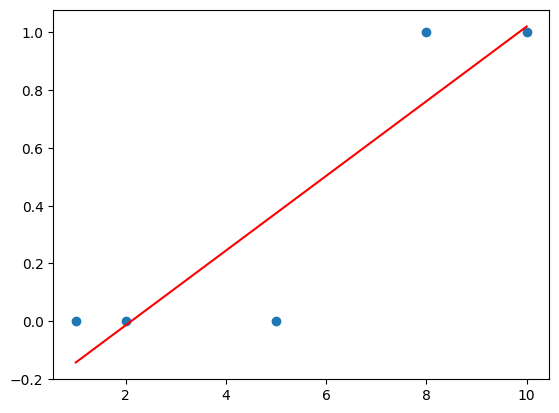

In [222]:
x = np.array([1,2,5,8,10])
y = np.array([0,0,0,1,1]) # 실제값
from scipy import stats
lm = stats.linregress(x,y) # 기울기와 y절편 => w, b
H = lm[0]*x + lm[1]
import matplotlib.pyplot as plt
plt.plot(x, H, 'r')
plt.scatter(x,y)

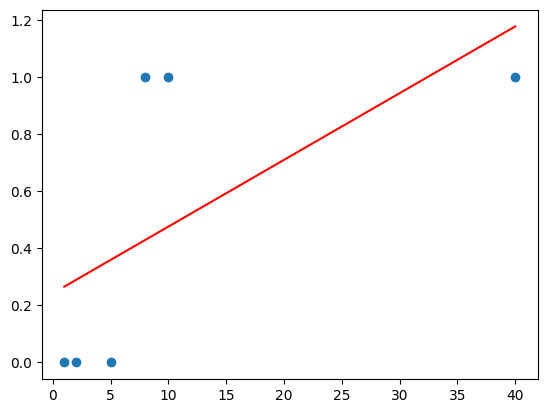

In [223]:
x = np.array([1,2,5,8,10,40])
y = np.array([0,0,0,1,1,1]) # 실제값
from scipy import stats
lm = stats.linregress(x,y) # 기울기와 y절편 => w, b
H = lm[0]*x + lm[1]
import matplotlib.pyplot as plt
plt.plot(x, H, 'r')
plt.scatter(x,y)

In [265]:
# 교안 50page
import numpy as np
X_data = np.array([[10,0],
                  [8,1],
                  [3,3],
                  [2,3],
                  [5,1],
                  [2,0],
                  [1,0]])
y_data = np.array([[1],[1],[1],[1],[0],[0],[0]])
# tensorflow 구현(tensor 그래프)
X = tf.placeholder(shape = (None,2), dtype = tf.float32)
y = tf.placeholder(shape = (None,1), dtype = tf.float32)
# 독립변수가 2개, 종속변수가 1개의 weight, bias
W = tf.Variable(tf.random.normal([2,1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis 설정
# H = X@W + b
logits = tf.matmul(X,W) + b
H = tf.sigmoid(logits)
# cost 함수
# cost = tf.reduce_mean(tf.square(H-y))
cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits = logits, labels=y))
# train
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# w,b, 초기화
sess = tf.Session()
sess.run(tf.global_variables_initializer())
# 학습
for step in range(1,8001) :
    _,cost_val = sess.run([train, cost], feed_dict={X:X_data,y:y_data})
    if step%800 == 0 :
        print(f'{step}번째 cost : {cost_val}')

800번째 cost : 0.3664109706878662
1600번째 cost : 0.3162619173526764
2400번째 cost : 0.2854526937007904
3200번째 cost : 0.2643226981163025
4000번째 cost : 0.2486676722764969
4800번째 cost : 0.23639917373657227
5600번째 cost : 0.22637499868869781
6400번째 cost : 0.2179207056760788
7200번째 cost : 0.21061328053474426
8000번째 cost : 0.2041732519865036


In [266]:
# 모델 사용
input_data = np.array([[5,2]])
predict = tf.cast(H>0.5, dtype = tf.float32)
sess.run(predict, feed_dict={X:input_data})

array([[1.]], dtype=float32)

In [268]:
# accuracy
correct = tf.equal(predict, y)
sess.run(correct, feed_dict={X:X_data, y : y_data})
accuracy = tf.reduce_mean(tf.cast(correct, dtype = tf.float32))
print('모델 정확도 :', sess.run(accuracy, feed_dict={X:X_data, y:y_data}))

모델 정확도 : 0.85714287


# 4. XOR
- x xor y : x==y -> 0, x!=y -> 1

In [282]:
X_data = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])
y_data = np.array([[0],[1],[1],[0]])
# x, y
X = tf.placeholder(shape=(None,2), dtype=tf.float32)
y = tf.placeholder(shape=(None,1), dtype=tf.float32)
# 독립변수 개수 2개, 종속변수 개수 1개 Weight, bias
W = tf.Variable(tf.random.normal(shape = (2,1)))
b = tf.Variable(tf.random.normal(shape = (1,)))
# Hypothesis
logits = X@W + b
H =tf.sigmoid(logits)
#cost
cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,labels=y))
# train
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# 세션 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer())
# 학습
for step in range(50000) :
    _,cost_val = sess.run([train,cost], feed_dict={X:X_data,y:y_data})
    if step%1000==0 :
        print(f'{step}번째 cost : {cost_val}')

0번째 cost : 1.0826959609985352
1000번째 cost : 0.6943643689155579
2000번째 cost : 0.6934740543365479
3000번째 cost : 0.6932610273361206
4000번째 cost : 0.6931890249252319
5000번째 cost : 0.6931633949279785
6000번째 cost : 0.6931536793708801
7000번째 cost : 0.6931499242782593
8000번째 cost : 0.6931483745574951
9000번째 cost : 0.6931477189064026
10000번째 cost : 0.6931474208831787
11000번째 cost : 0.6931473016738892
12000번째 cost : 0.6931472420692444
13000번째 cost : 0.6931471824645996
14000번째 cost : 0.6931471824645996
15000번째 cost : 0.6931471824645996
16000번째 cost : 0.6931471824645996
17000번째 cost : 0.6931471824645996
18000번째 cost : 0.6931471824645996
19000번째 cost : 0.6931471824645996
20000번째 cost : 0.6931471824645996
21000번째 cost : 0.6931471824645996
22000번째 cost : 0.6931471824645996
23000번째 cost : 0.6931471824645996
24000번째 cost : 0.6931471824645996
25000번째 cost : 0.6931471824645996
26000번째 cost : 0.6931471824645996
27000번째 cost : 0.6931471824645996
28000번째 cost : 0.6931471824645996
29000번째 cost : 0.6931471824

In [283]:
# accuracy
predict = tf.cast(H>0.5, dtype = tf.float32)
correct = tf.equal(predict, y)
sess.run(correct, feed_dict={X:X_data, y : y_data})
accuracy = tf.reduce_mean(tf.cast(correct, dtype = tf.float32))
print('모델 정확도 :', sess.run(accuracy, feed_dict={X:X_data, y:y_data}))

모델 정확도 : 0.25


# 5. DeepLearning XOR 예제

In [288]:
X_data = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])
y_data = np.array([[0],[1],[1],[0]])
# x, y
X = tf.placeholder(shape=(None,2), dtype=tf.float32)
y = tf.placeholder(shape=(None,1), dtype=tf.float32)
# layer1 : (입력 2개 출력 4개)
# 독립변수 개수 2개, 종속변수 개수 1개 Weight, bias
W1 = tf.Variable(tf.random.normal(shape = (2,4)))
b1 = tf.Variable(tf.random.normal(shape = (4,)))
# Hypothesis
layer1 =tf.nn.relu(tf.matmul(X,W1) + b1)
# layer2 : 입력4개 출력 1개
W2 = tf.Variable(tf.random.normal(shape = (4,1)))
b2 = tf.Variable(tf.random.normal(shape = (1,)))
# Hypothesis
logits = tf.matmul(layer1,W2) + b2
H = tf.sigmoid(logits)
#cost
cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,labels=y))
# train
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# 세션 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer())
# 학습
for step in range(10000) :
    _,cost_val = sess.run([train,cost], feed_dict={X:X_data,y:y_data})
    if step%1000==0 :
        print(f'{step}번째 cost : {cost_val}')

0번째 cost : 0.6580614447593689
1000번째 cost : 0.4747123420238495
2000번째 cost : 0.3017558455467224
3000번째 cost : 0.1771308183670044
4000번째 cost : 0.12069346010684967
5000번째 cost : 0.08914002031087875
6000번째 cost : 0.06924697756767273
7000번째 cost : 0.05584048479795456
8000번째 cost : 0.04630193114280701
9000번째 cost : 0.039276860654354095


In [289]:
# accuracy
predict = tf.cast(H>0.5, dtype = tf.float32)
correct = tf.equal(predict, y)
sess.run(correct, feed_dict={X:X_data, y : y_data})
accuracy = tf.reduce_mean(tf.cast(correct, dtype = tf.float32))
print('모델 정확도 :', sess.run(accuracy, feed_dict={X:X_data, y:y_data}))

모델 정확도 : 1.0


## layer층  x_data 2개 -> 4 -> 1을 
## layer층 x_data 2개 -> 10 -> 20 -> 10 -> 1
                        입력층   hidden layer(relu)  | 출력층(sigmoid, softmax)

In [319]:
X_data = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])
y_data = np.array([[0],[1],[1],[0]])
# x, y
X = tf.placeholder(shape=(None,2), dtype=tf.float32)
y = tf.placeholder(shape=(None,1), dtype=tf.float32)
# layer1 : (입력 2개 출력 10개) | 입력층
W1 = tf.Variable(tf.random.normal(shape = (2,10)))
b1 = tf.Variable(tf.random.normal(shape = (10,)))
# Hypothesis
layer1 =tf.nn.relu(tf.matmul(X,W1) + b1)
# layer2 : 입력10개 출력 20 | hidden layer
W2 = tf.Variable(tf.random.normal(shape = (10,20)))
b2 = tf.Variable(tf.random.normal(shape = (20,)))
# Hypothesis
layer2 =tf.nn.relu(tf.matmul(layer1,W2) + b2)
# layer3 : 입력20개 출력 10개 | hidden layer
W3 = tf.Variable(tf.random.normal(shape = (20,10)))
b3 = tf.Variable(tf.random.normal(shape = (10,)))
# Hypothesis
layer3 =tf.nn.relu(tf.matmul(layer2,W3) + b3)
# layer4 : 입력10개 출력 1개 | 출력층
W4 = tf.Variable(tf.random.normal(shape = (10,1)))
b4 = tf.Variable(tf.random.normal(shape = (1,)))
# Hypothesis
logits = tf.matmul(layer3,W4) + b4
H = tf.nn.sigmoid(logits)
#cost
cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,labels=y))
# train
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# 세션 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer())
# 학습
for step in range(300) :
    _,cost_val = sess.run([train,cost], feed_dict={X:X_data,y:y_data})
    if step%15==0 :
        print(f'{step}번째 cost : {cost_val}')

0번째 cost : 2.094325065612793
15번째 cost : 0.24878253042697906
30번째 cost : 0.11936702579259872
45번째 cost : 0.07801025360822678
60번째 cost : 0.05713579058647156
75번째 cost : 0.04484245553612709
90번째 cost : 0.03688767924904823
105번째 cost : 0.031249072402715683
120번째 cost : 0.027385015040636063
135번째 cost : 0.024680431932210922
150번째 cost : 0.02242128737270832
165번째 cost : 0.020498502999544144
180번째 cost : 0.018800955265760422
195번째 cost : 0.01736939698457718
210번째 cost : 0.01612413302063942
225번째 cost : 0.015066423453390598
240번째 cost : 0.014099916443228722
255번째 cost : 0.013261997140944004
270번째 cost : 0.01251121237874031
285번째 cost : 0.011827588081359863


In [320]:
# accuracy
predict = tf.cast(H>0.5, dtype = tf.float32)
correct = tf.equal(predict, y)
sess.run(correct, feed_dict={X:X_data, y : y_data})
accuracy = tf.reduce_mean(tf.cast(correct, dtype = tf.float32))
print('모델 정확도 :', sess.run(accuracy, feed_dict={X:X_data, y:y_data}))

모델 정확도 : 1.0
